# **MÓDULO 27 - Projeto de Doenças Cardiovasculares - Regressão Logística**


Assim como na aula que trabalhamos com uma base de dados nova, com um contexto de modelo de propensão a compra de carros, para a atividade de vocês achei interessante trazer também novos desafios.

Nessa tarefa iremos construir um modelo que nos ajude a prever doenças cardiovasculares, a base contém dados reais.

age - idade dos pacientes

gender - genero (2 mulheres) (1 homens)

height - altura dos pacientes

weight - peso dos pacientes

gluc - glicose

smoke - fumante (1) não fumante (0)

alco - consume alcool (1) não consome (0)

active - realiza atividades fisicas (1) não realiza (0)

cardio_disease - tem doença cardio (1) não tem (0) - Variável target


Seu objetivo é utilizar esses dados históricos dos pacientes e construir um bom modelo de regressão capaz de indicar se novos pacientes estão propensos a doenças cariovasculares ou não.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, classification_report
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import numpy as np

# 1) Comece carregando e tratando a base de dados.
Assim como na aula essa nova base não passou por pré processamento nenhum então nessa etapa, carrega os dados, verifique os tipos de dados, verifique se temos dados faltantes e outliers.
Quando necessário realize o tratamento.


Inicialmente, os dados foram importados a partir de um arquivo no formato csv, procendendo-se, em seguida, à verificação e validação do tipo de dado atribuído a cada coluna visando assegurar a consistência estrutural da base de dados.

In [ ]:
base = pd.read_csv("CARDIO_BASE.csv", delimiter=';')

In [ ]:
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             10000 non-null  int64 
 1   gender          10000 non-null  int64 
 2   height          10000 non-null  int64 
 3   weight          10000 non-null  object
 4   cholesterol     10000 non-null  int64 
 5   gluc            10000 non-null  int64 
 6   smoke           10000 non-null  int64 
 7   alco            10000 non-null  int64 
 8   active          10000 non-null  int64 
 9   cardio_disease  10000 non-null  int64 
dtypes: int64(9), object(1)
memory usage: 781.4+ KB


In [ ]:
#Realizando transformação dos tipos de dados para tipos mais adequados
#O campo age e gender já estão no formato ideal, portanto não serão alterados
base['height'] = base['height'].astype(float)
base['weight'] = base['weight'].astype(str).str.replace(',','.', regex=False).astype(float)
#Os campos restantes, cholesterol, gluc, smoke, alco, active e cardio_disease estão no formato ideal, inteiro, portanto não serão alterados
#Agora checaremos novamente nossa base de dados
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             10000 non-null  int64  
 1   gender          10000 non-null  int64  
 2   height          10000 non-null  float64
 3   weight          10000 non-null  float64
 4   cholesterol     10000 non-null  int64  
 5   gluc            10000 non-null  int64  
 6   smoke           10000 non-null  int64  
 7   alco            10000 non-null  int64  
 8   active          10000 non-null  int64  
 9   cardio_disease  10000 non-null  int64  
dtypes: float64(2), int64(8)
memory usage: 781.4 KB


In [ ]:
cols = ['smoke', 'alco', 'active', 'cardio_disease']
print(base[base[cols].gt(1).any(axis=1)])
cols2 = ['cholesterol','gluc']
print(base[base[cols2].gt(3).any(axis=1)])

Empty DataFrame
Columns: [age, gender, height, weight, cholesterol, gluc, smoke, alco, active, cardio_disease]
Index: []
Empty DataFrame
Columns: [age, gender, height, weight, cholesterol, gluc, smoke, alco, active, cardio_disease]
Index: []


Os dados apresentaram, em sua maioria, tipagens compatíveis com a natureza de cada variável, como nos campos de idade (age), gênero (gender) e glicose (gluc). Da mesma forma, variáveis categóricas binárias, cuja a resposta esperada seria "sim" ou "não", também foram adequadamente representados em formato inteiro (0,1).

Entretanto, nos campos de altura e peso foi necessário ajustar a tipagem, sendo convertidos para o formato float, a fim de garantir uma melhor representação de seus valores reais.

Em seguida, foi aplicada a função describe para obtenção de um resumo estatístico descritivo da base, permitindo analisar o comportamento das variáveis e identificar indícios de outliers, dispersões atípicas e eventuais inconsistências em seus valores.

In [ ]:
base.describe()

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,53.288300,1.345400,164.308200,74.303710,1.365000,1.222200,0.089000,0.053700,0.797200,0.503100
std,6.796234,0.475522,8.178796,14.566353,0.677658,0.565561,0.284758,0.225436,0.402105,0.500015
min,30.000000,1.000000,70.000000,30.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,1.000000,159.000000,65.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,165.000000,72.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
75%,58.000000,2.000000,170.000000,82.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,65.000000,2.000000,250.000000,200.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


Ao analisar as métricas das variáveis quantitativas, idade, altura e peso, observou-se a ausencia de indícios claros de comportamentos inesperados, dado que a média e a mediana apresentam valores relativamente próximos. Quando avaliamos os quartis (25 e 75%), esse padrão se mantém para a variável idade, indicando coerência na distribuição e ausência de afastamentos relevantes em relação aos limites mínimo e máximo.

Entretanto, para as variáveis altura e peso, os valores mínimos e máximos evidenciam maior amplitude, sugerindo a presença de valores extremos e a necessidade de investigação adicional. Para aprofundar a análise e compreender melhor a distribuição dessas variáveis, os dados serão representados por meio de boxplots, permitindo visualizar dispersão, assimetria e potenciais outliers.

In [ ]:
cols = ['age', 'height', 'weight']
fig = make_subplots(rows = 1, cols =3, subplot_titles = cols)

c = 0
for i in cols:
  c += 1
  fig.add_trace(go.Box(y=base[i], name=i), row=1, col=c)

fig.update_layout(title='Boxplot das variáveis numéricas', showlegend=False)
fig.show()

A análise dos boxplots das variáveis quantitativas confirma a hipótese levantada anteriormente. No caso da variável idade, observa-se um conjunto de dados mais bem comportado, com maior concentração em torno da tendência central, e a presença de um único ponto identificado como potencial outlier, correspondente a uma idade consideravelmente abaixo do limite mínimo esperado.

Embora esse valor ainda seja plausível e não indique um erro de preenchimento, sua baixa representatividade na amostra pode gerar viés durante o treinamento do modelo de regressão logística, induzindo conclusões erroneas para faixas etárias pouco observadas. Por isso, optou-se por remover esse ponto identificado como outlier.

In [ ]:
outliers_altura = base[(base['height'] <= 146) | (base['height'] > 186)]
print(outliers_altura)
print(len(base))
print(f"Quantidade de outliers:  {len(outliers_altura)} - {((len(outliers_altura)/len(base)) * 100)}")
base = base.drop(outliers_altura.index)

      age  gender  height  weight  cholesterol  gluc  smoke  alco  active  \
62     56       2   187.0   115.0            1     1      0     1       1   
76     56       2   188.0   105.0            1     1      0     0       1   
224    60       2    76.0    55.0            1     1      0     0       1   
249    50       1   142.0    61.0            1     1      0     0       1   
360    54       1   144.0    44.0            1     1      0     0       1   
...   ...     ...     ...     ...          ...   ...    ...   ...     ...   
9776   62       2   130.0    90.0            1     1      0     0       1   
9784   43       2   192.0   101.0            1     1      0     0       1   
9835   58       1   146.0    78.0            1     1      0     0       1   
9889   44       1   145.0    40.0            1     1      0     0       1   
9937   61       2   146.0    46.0            2     1      0     0       1   

      cardio_disease  
62                 0  
76                 1  
224   

In [ ]:
outliers_peso = base[(base['weight'] < 40) | (base['weight'] > 105)]
print(outliers_peso)
print(f"Quantidade de outliers:  {len(outliers_peso)} - {((len(outliers_peso)/len(base)) * 100)}")
base = base.drop(outliers_peso.index)

      age  gender  height  weight  cholesterol  gluc  smoke  alco  active  \
15     46       2   172.0   112.0            1     1      0     0       0   
46     50       1   162.0   107.0            2     1      0     0       1   
83     54       1   152.0   110.0            1     1      0     0       1   
196    62       1   176.0   108.0            1     1      0     0       0   
267    48       1   165.0   115.0            1     1      0     0       1   
...   ...     ...     ...     ...          ...   ...    ...   ...     ...   
9866   47       1   175.0   113.0            1     1      1     0       1   
9895   62       1   161.0   115.0            2     1      0     0       0   
9918   64       1   159.0   106.0            3     1      0     0       0   
9962   44       2   184.0   138.0            1     1      0     0       1   
9983   52       2   173.0   108.0            1     1      0     0       1   

      cardio_disease  
15                 1  
46                 1  
83    

In [ ]:
outliers_idade = base[(base['age'] < 39)]
print(outliers_idade)
base = base.drop(outliers_idade.index)

      age  gender  height  weight  cholesterol  gluc  smoke  alco  active  \
6219   30       1   175.0    59.0            1     1      0     0       1   

      cardio_disease  
6219               0  


Já os boxplots de altura e peso evidenciaram uma distribuição significativamente mais dispersa, com presença de múltiplos valores extremos. Ao avaliar a representatividade desses outliers, observou-se que eles correspondem a aproximadamente 2,5% da base para peso e 1,5% para altura.

Considerando que o modelo de regressão logística pode ser sensível a outliers, optou-se pela remoção integral desses registros, ainda que parte deles não indicasse necessariamente inconsistência de preenchimento.

In [ ]:

cols = ['age', 'height', 'weight']
fig = make_subplots(rows = 1, cols =3, subplot_titles = cols)

c = 0
for i in cols:
  c += 1
  fig.add_trace(go.Box(y=base[i], name=i), row=1, col=c)

fig.update_layout(title='Boxplot das variáveis numéricas', showlegend=False)
fig.show()

Após a remoção dos valores extremos, a nova plotagem dos boxplots das variáveis numéricas evidenciou um conjunto de dados significativamente menos disperso e mais consistente. Embora altura e peso ainda apresentem certa variabilidade e indícios pontuais de possíveis outliers, esses valores encontram-se mais próximos da faixa esperada para a população analisada, reduzindo o risco de influência desproporcional no treinamento e na estabilidade do modelo.

# 2) Agora é hora de explorar os dados com uma análise bem completa.
Plote pelo menos 3 gráficos analisando o comportamento da variável cardio com outras variaveis da sua preferência (análise bivariada). Não se esqueça de trazer insights acerca do analisado.


Para iniciar a etapa de exploração dos dados, foram definidas labels para cada variável, com o objetivo de padronizar e facilitar a visualização nas análises gráficas. Em seguida, priorizou-se a avaliação das variáveis categóricas, mapeando a proporção de registros em cada categoria relacionada a tabagismo (smoke), consumo de álcool (alco), prática de atividade física (active), gênero (gender), colesterol (cholesterol) e glicose (gluc).

In [ ]:
def contagem(df, category_col):
  counts = (df.groupby(['cardio_label', category_col]).size().reset_index(name='count'))
  return counts

base['gender_label'] = base['gender'].map({1:'Homem', 2:'Mulher'})
base['cardio_label'] = base['cardio_disease'].map({0:'Sem DCV', 1:'Com DCV'})
base['smoke_label'] = base['smoke'].map({0:'Não Fumante', 1:'Fumante'})
base['alco_label'] = base['alco'].map({0:'Não consome Alcool', 1:'Consome Alcool'})
base['active_label'] = base['active'].map({0:'Sedentário', 1:'Ativo'})
base['cholesterol_label'] = base['cholesterol'].map({1:'Normal', 2:'Acima do normal', 3:'Alto'})
base['gluc_label'] = base['gluc'].map({1:'Normal', 2:'Acima normal', 3:'Alto'})

labels = ['smoke_label', 'alco_label', 'active_label', 'gender_label', 'cholesterol_label', 'gluc_label', 'cardio_label']
titulos = ['Fumante', 'Consumo de Alcool', 'Atividade Física', 'Gênero', 'Colesterol', 'Glicose', 'Doenças Cardiovasculares']

In [ ]:
fig = make_subplots(rows=3, cols=3, subplot_titles=titulos)

for c, label in enumerate(labels):
  counts = base[label].value_counts().reset_index()
  counts.columns = [label, 'count']
  row = c // 3 + 1
  col = c % 3 + 1

  fig.add_trace(go.Bar(x=counts[label], y=counts['count'], showlegend=False), row=row, col=col)

fig.update_layout(title='Distribuição das variáveis categóricas', yaxis_title='Número de indivíduos')

fig.show()

Ao plotar as variáveis categóricas, observou-se desbalanceamento entre as categorias na maior parte dos atributos, com exceção da variável doenças cardiovasculares (cardio_disease), a variável-alvo do dataset. Esse desbalanceamento pode introduzir viés no modelo em desenvolvimento, uma vez que categorias pouco representadas tendem a ser menos bem aprendidas e podem comprometer a capacidade de generalização.

Diante disso, considerou-se pertinente aprofundar a análise, verificando a incidência dessas categorias separadamente entre os registros com e sem doenças cardiovasculares, a fim de avaliar o grau de associação entre as variáveis explicativas e a variável objetivo.

In [ ]:
fig = make_subplots(rows=3, cols=3, specs=[[{'colspan':3}, None, None],[{}, {}, {}],[{}, {}, {}]], subplot_titles=['Incidência de DCV na base']+titulos)

inc = base['cardio_label'].value_counts().reindex(['Sem DCV','Com DCV']).reset_index()
inc.columns = ['cardio_label', 'count']
fig.add_trace(go.Bar(x=inc['cardio_label'], y=inc['count'], showlegend=False), row=1, col=1)

for c, label in enumerate(labels):
  if c >= 6: break
  label_df = contagem(base, label)
  label_df['cardio_label'] = pd.Categorical(label_df['cardio_label'], categories= ['Sem DCV','Com DCV'], ordered=True)

  label_df = label_df.sort_values('cardio_label')

  row = c // 3 + 2
  col = c % 3 + 1

  for categoria in label_df[label].dropna().unique():
    subset=label_df[label_df[label]== categoria]
    fig.add_trace(go.Bar(x=subset['cardio_label'], y=subset['count'], name=categoria, showlegend=False), row=row, col=col)

fig.update_layout(barmode='stack', yaxis_title='Número de indivíduos',title='Contagem por status cardiovascular')

fig.show()

Ao analisar os gráficos de incidência de cada categoria em relação à variável-alvo, observa-se que, apesar do desbalanceamento interno entre as classes de cada variável, a distribuição se mantém relativamente homogênea entre os registros com e sem DCV.

A principal exceção é a variável colesterol, que apresenta um padrão mais evidente: pacientes classificados com colesterol elevado tendem a aparecer com maior frequência entre os registros com doenças cardiovasculares, sugerindo uma possível associação mais forte desse fator com a ocorrência de DCV no dataset. Entretanto, a baixa representatividade de algumas categorias de colesterol pode limitar a capacidade do modelo em capturar essa diferença de forma consistente.

Por fim, para a exploração das variáveis numéricas, optou-se por comparar sua distribuição entre as categorias sem e com DCV por meio de boxplots. Contudo, visando aumentar a interpretabilidade da análise, em vez de avaliar separadamente altura, peso e idade, foi criada uma variável derivada adicional: o IMC (Índice de Massa Corporal).

O IMC foi calculado a partir de peso e altura do indivíduo, permitindo uma associação mais direta e comparável do grau de obesidade com a ocorrência de doenças cardiovasculares, sendo, portanto, um indicador mais informativo do que o peso isoladamente para fins analíticos e de modelagem.

In [ ]:
base['imc'] = base['weight']/(base['height']/100)**2
base['age_group'] = pd.cut(base['age'], bins = [0, 40, 50, 60, 70], labels=['<40', '40-49', '50-59', '60+'])

fig = make_subplots(rows = 1, cols=2, subplot_titles= ['Distribuição de idade por doenças cardiovasculares', 'IMC por doenças cardiovasculares'])
c=0
labels = ['age', 'imc']

for label in labels:
  c+=1
  for condition in base['cardio_label'].unique():
    fig.add_trace(go.Box(y=base.loc[base['cardio_label'] == condition, label], name=condition, boxmean=True), row=1, col=c)
fig.update_layout(title='Idade e IMC por Doenças Cardiovaculares', yaxis_title='Idade', yaxis2_title='IMC')
fig.show()

Ao observar os boxplots, nota-se que os registros com DCV tendem a se concentrar em faixas de idade mais elevadas e apresentam, em média, IMC ligeiramente superior em comparação ao grupo sem DCV. Ainda assim, há sobreposição relevante entre as distribuições (medianas e intervalos interquartis próximos), indicando que, embora exista uma tendência, a diferença não é suficientemente pronunciada para, isoladamente, sustentar a hipótese de uma correlação forte. Esses achados sugerem que idade e IMC podem atuar como fatores contributivos, mas provavelmente em conjunto com outras variáveis explicativas do modelo.

Como etapa final da análise exploratória, optou-se por investigar a existência de uma tendência de aumento do IMC com a idade, segmentando a avaliação por gênero (homens e mulheres). Essa análise permite identificar possíveis padrões de comportamento distintos entre os grupos e avaliar se a relação entre idade e IMC apresenta variação relevante conforme o gênero.

In [ ]:
fig = make_subplots(rows=2, cols=1, subplot_titles=['Idade vs IMC em homens','Idade vs IMC em mulheres'])
base_homem = base[base['gender_label'] == 'Homem']
base_mulher = base[base['gender_label'] == 'Mulher']

fig.add_trace(go.Scatter(y = base_homem['age'], x=base_homem['imc'], mode='markers', name='Homem', opacity=0.6, marker=dict(color='green')), row=1, col=1)

coef_h = np.polyfit(base_homem['imc'], base_homem['age'], 1)
x_h = np.linspace(base_homem['imc'].min(), base_homem['imc'].max(), 100)
y_h = coef_h[0] * x_h + coef_h[1]
fig.add_trace(go.Scatter(y = y_h, x = x_h, mode='lines', name='Tendência', opacity=0.9, line=dict(color='blue')), row=1, col=1)

fig.add_trace(go.Scatter(y = base_mulher['age'], x=base_mulher['imc'], mode='markers', name='Mulher', opacity=0.6, marker=dict(color='orange')), row=2, col=1)

coef_m = np.polyfit(base_mulher['imc'], base_mulher['age'], 1)
x_m = np.linspace(base_mulher['imc'].min(), base_mulher['imc'].max(), 100)
y_m = coef_m[0] * x_m + coef_m[1]
fig.add_trace(go.Scatter(y = y_m, x = x_m, mode='lines', name='Tendência', opacity=0.9, line=dict(color='red')), row=2, col=1)

fig.update_layout(title='Idade vs IMC por gênero com linha de tendência',xaxis_title='IMC', yaxis_title='Idade',xaxis2_title='IMC', yaxis2_title='Idade',showlegend=False)
fig.show()

A partir dos gráficos de Idade vs IMC por gênero, é possível observar a presença de uma tendência positiva discreta entre o IMC e idade tanto em homens quanto em mulheres, indicada pela inclinação das linhas de tendência. Porém, a dispersão dos pontos ao longo de toda a faixa etária mostra que essa relação provávelmente é fraca e não se comporta como um padrão linear bem definido e não é possível dizer que o IMC aumenta conforme a idade para a maioria dos indivíduos dessa base de dados.

# 3) Nessa etapa você deve trazer a matriz de correlação e apontar insights acerca das variáveis com um relacionamento mais forte entre si.



Construiu-se uma matriz de correlação com o objetivo de avaliar o grau de relacionamento linear entre as variáveis do conjunto de dados. De forma geral, é possível observar uma correlação fraca entre as variáveis sem muitos indícios de dependências lineares expressivas. A associação mais relevante indicada pela matriz de correlação foi entre o colesterol e a glicose, porém sua magnitude ainda é moderada.

Quando avaliamos a variável-alvo, sua correlação mais forte é com a idade. Porém trata-se de uma correlação fraca, o que sugere que a presença das DCV não decorre de uma única variável explicativa, e sim de uma combinação de fatores.

In [ ]:
corr_matrix = base[['age','imc', 'gluc', 'cholesterol', 'gender', 'smoke', 'alco', 'active', 'imc','cardio_disease']].corr()
fig = go.Figure(data=go.Heatmap(z=corr_matrix.values, x=corr_matrix.columns, y=corr_matrix.index, colorscale='RdBu', zmin=-1, zmax=1, colorbar=dict(title="Correlação")))
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix.columns)):
        fig.add_annotation(
            x=corr_matrix.columns[j],
            y=corr_matrix.index[i],
            text=f"{corr_matrix.values[i, j]:.2f}",
            showarrow=False,
            font=dict(size=10)
        )
fig.update_layout(title='Mapa de correlação de variaveis numéricas', xaxis_title='Variables', yaxis_title='Variables')
fig.show()

# 4) Essa é a sua última etapa pré modelo. Você deve:

A) Separar a base em treino e teste.

B) Você considera que essa base precisa que os dados sejam padronizados? Se sim, porque? Se acredita que devem, então realize essa etapa.

C) Verifique se os dados estão balanceados, se não, faça o balanceamento.


D) Visualize as bases de treino, teste (X E Y) e verifique se está tudo adequado.

Para realizar a separação da base em treino e teste, é necessário, previamente, ajustar o conjunto de variáveis, removendo colunas que não serão utilizadas no treinamento do modelo. Nesse processo, exclui-se a variável-alvo (cardio_disease), as variáveis de label (utilizadas apenas para fins de visualização) e os campos de altura e peso, uma vez que foram substituídos pela variável derivada IMC, considerada mais adequada para representar o índice de obesidade no contexto da análise.

In [ ]:
x = base.drop(['height', 'weight', 'cardio_disease', 'gender_label', 'cardio_label', 'smoke_label', 'alco_label', 'active_label', 'cholesterol_label', 'gluc_label', 'age_group'],axis=1)
y = base['cardio_disease']
x_treino, x_teste, y_treino, y_teste = train_test_split(x,y,test_size=0.25,random_state=42)

Como estamos trabalhando com regressão logística, a padronização dos dados é importante por ser mais sensivel a escala das features, já que tenta encontrar um plano de separação no espaço das features para separar as classes. Como a regressão atribui um peso para cada feature, a escala delas pode afetar significativamente o treinamento. Onde as features de maior valor podem dominar a função de custo e gradientes e enviesar o modelo. Por isso é necessário padroniza-las. No entanto, esse dataset possui muitas variáveis categóricas que não necessitam de padronização, por isso prezou-se por manter o formato original dessas variáveis e padronizar apenas as variáveis contínuas, como idade ('age'), e imc.

In [ ]:
sc = StandardScaler()

cols_variaveis_continuas = ['age','imc']

x_treino[cols_variaveis_continuas] = sc.fit_transform(x_treino[cols_variaveis_continuas])
x_teste[cols_variaveis_continuas] = sc.fit_transform(x_teste[cols_variaveis_continuas])

Após padronizar os dados, iremos verificar numericamente se a variável objetivo está balanceada.

In [ ]:
print(f'Treino %: {y_treino.value_counts(normalize=True).mul(100).round(2)}')
print(f'Teste %: {y_teste.value_counts(normalize=True).mul(100).round(2)}')

Treino %: cardio_disease
0    50.38
1    49.62
Name: proportion, dtype: float64
Teste %: cardio_disease
0    50.35
1    49.65
Name: proportion, dtype: float64


Ao analisar a distribuição percentual da variável objetivo nas bases de treino e teste, observou-se que as proporções entre as classes se mantêm semelhantes em ambos os conjuntos. Isso indica que a separação preservou o balanceamento da variável alvo, reduzindo o risco de viés introduzido pelo particionamento dos dados e permitindo uma comparação mais justa do desempenho do modelo.

Apesar disso, foi identificada na etapa de exploração dos dados uma subrepresentação em algumas categorias de variáveis categóricas que não são o alvo. Esse desbalanceamento por categoria pode limitar a capacidade de generalização do algoritmo, pois o modelo terá menos exemplos para aprender padrões associados a essas classes, podendo apresentar desempenho inferior quando encontrar essas categorias em novos dados.

Portanto, agora iremos verificar as bases criadas para garantir que elas estão coerentes.


In [ ]:
print("Verificação das dimensões de cada base")
print(f"x_treino: {x_treino.shape}")
print(f"y_treino: {y_treino.shape}")
print(f"x_teste: {x_teste.shape}")
print(f"y_teste: {y_teste.shape}")

Verificação das dimensões de cada base
x_treino: (7194, 8)
y_treino: (7194,)
x_teste: (2399, 8)
y_teste: (2399,)


In [ ]:
cols = x.columns

x_treino = pd.DataFrame(x_treino, columns=cols)
x_teste  = pd.DataFrame(x_teste, columns=cols)

In [ ]:
print(x_treino.info())
print(x_treino.describe())
x_treino

<class 'pandas.core.frame.DataFrame'>
Index: 7194 entries, 4217 to 7582
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          7194 non-null   float64
 1   gender       7194 non-null   int64  
 2   cholesterol  7194 non-null   int64  
 3   gluc         7194 non-null   int64  
 4   smoke        7194 non-null   int64  
 5   alco         7194 non-null   int64  
 6   active       7194 non-null   int64  
 7   imc          7194 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 505.8 KB
None
                age       gender  cholesterol         gluc        smoke  \
count  7.194000e+03  7194.000000  7194.000000  7194.000000  7194.000000   
mean  -2.276621e-16     1.340979     1.353350     1.215040     0.088407   
std    1.000070e+00     0.474071     0.667385     0.558335     0.283906   
min   -2.109164e+00     1.000000     1.000000     1.000000     0.000000   
25%   -7.790390e-01     1.000000     1.00000

,age,gender,cholesterol,gluc,smoke,alco,active,imc
4217,0.994461,2,1,1,0,1,1,-0.422396
3948,-1.813580,2,1,1,0,0,0,-1.104127
1299,-0.483456,2,1,1,0,0,1,-0.671715
5824,-1.665789,2,1,1,0,0,1,-0.323372
5929,-1.074622,1,1,1,0,0,1,-1.390229
...,...,...,...,...,...,...,...,...
5991,0.846669,1,1,1,0,0,1,0.096793
5419,-0.483456,1,1,1,0,0,1,-0.947140
5630,-1.665789,1,1,1,0,0,1,-0.355849
895,0.698877,2,1,1,0,0,1,-1.291742


In [ ]:
print(x_teste.info())
print(x_teste.describe())
x_teste

<class 'pandas.core.frame.DataFrame'>
Index: 2399 entries, 6161 to 7183
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          2399 non-null   float64
 1   gender       2399 non-null   int64  
 2   cholesterol  2399 non-null   int64  
 3   gluc         2399 non-null   int64  
 4   smoke        2399 non-null   int64  
 5   alco         2399 non-null   int64  
 6   active       2399 non-null   int64  
 7   imc          2399 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 168.7 KB
None
                age       gender  cholesterol         gluc        smoke  \
count  2.399000e+03  2399.000000  2399.000000  2399.000000  2399.000000   
mean   2.413890e-16     1.348479     1.366820     1.226761     0.085035   
std    1.000208e+00     0.476588     0.677654     0.568363     0.278993   
min   -2.071844e+00     1.000000     1.000000     1.000000     0.000000   
25%   -7.674794e-01     1.000000     1.00000

,age,gender,cholesterol,gluc,smoke,alco,active,imc
6161,0.681815,2,3,1,0,0,1,0.270631
9492,-1.926915,2,1,1,0,0,1,-0.574618
40,0.102097,1,1,1,0,0,0,-0.430665
6274,0.826744,2,1,1,0,0,1,0.328211
1918,-0.912409,1,1,1,0,0,1,0.491430
...,...,...,...,...,...,...,...,...
3039,0.391956,1,1,1,0,0,1,-0.567120
8456,-1.347197,2,1,1,0,0,1,-1.455984
225,-0.767479,1,1,1,0,0,1,-0.092945
8984,-1.637056,2,1,1,0,0,1,0.560614


In [ ]:
y_treino

,cardio_disease
4217,0
3948,0
1299,1
5824,1
5929,0
...,...
5991,0
5419,0
5630,0
895,0


In [ ]:
y_teste

,cardio_disease
6161,1
9492,0
40,0
6274,1
1918,0
...,...
3039,0
8456,0
225,0
8984,0


Após as verificações, observou-se que as bases de treino e teste foram geradas com as dimensões esperadas, e que o conjunto de variáveis explicativas em treino e teste possui a mesma estrutura, isto é, mesmas colunas e mesma ordem. Além disso, as variáveis contínuas age e imc foram padronizadas, o que reduziu a influência de escala e trouxe os valores para uma faixa comparável, contribuindo para a estabilidade do treinamento.

Com esses pontos validados, é possível avançar para a etapa de modelagem, aplicando o algoritmo de Regressão Logística para resolver o problema de classificação.

# 5) Realize a etapa de treinamento do modelo:

A) Faça o treinamento do modelo.

B) Traga o intercept e os coeficientes.

c) Avalie as métricas do modelo treinado

D) Justifique se te parece que o modelo tem feito boas previsões ou não.

Após a etapa de limpeza e preparação dos dados, aplica-se o algoritmo de Regressão Logística para treinar um modelo de classificação capaz de estimar a probabilidade da ocorrência da classe positiva da variável objetivo a partir das variáveis explicativas selecionadas.

In [ ]:
logistic_cardio = LogisticRegression(random_state=0)
logistic_cardio.fit(x_treino, y_treino)

LogisticRegression(random_state=0)

In [ ]:
logistic_cardio.intercept_

array([-0.65703856])

In [ ]:
logistic_cardio.coef_

array([[ 0.44362202,  0.13901883,  0.59372916, -0.14190713, -0.20406775,
        -0.02019735, -0.18422278,  0.32459299]])

Após criar o modelo é possível estimar a probabilidade da classe positiva a partir de um peditor linear z, dado pela seguinte equação:

In [ ]:
beta0 = float(logistic_cardio.intercept_[0])
betas = logistic_cardio.coef_[0]
features = list(x_treino.columns)

eq = f"z = {beta0:.4f}"
for b, f in zip(betas, features):
    sinal = " + " if b >= 0 else " - "
    eq += f"{sinal}{abs(b):.4f}*{f}"

prob = "p(y=1|x) = 1/(1 + exp(-z))"

print(eq)
print(prob)


z = -0.6570 + 0.4436*age + 0.1390*gender + 0.5937*cholesterol - 0.1419*gluc - 0.2041*smoke - 0.0202*alco - 0.1842*active + 0.3246*imc
p(y=1|x) = 1/(1 + exp(-z))


Com a equação definida, o próximo passo é avaliar o desempenho do modelo utilizando os dados de treino, verificando sua capacidade de aprender e identificar padrões presentes na base em que foi ajustado.

In [ ]:
previsoes = logistic_cardio.predict(x_treino)
relatorio = classification_report(y_treino, previsoes)
print('Relatório de Classificação:')
print(relatorio)

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.63      0.67      0.65      3624
           1       0.64      0.60      0.62      3570

    accuracy                           0.63      7194
   macro avg       0.63      0.63      0.63      7194
weighted avg       0.63      0.63      0.63      7194



O modelo apresentou acurácia de 0.63 no conjunto de treino, indicando um desempenho moderado na classificação. Para a classe 0, obteve precision = 0.63, recall = 0.67 e F1-score = 0.65, mostrando melhor capacidade de identificar corretamente os casos negativos, com maior sensibilidade para essa classe. Para a classe 1, obteve precision = 0.64, recall = 0.60 e F1-score = 0.62, o que sugere maior dificuldade em recuperar todos os casos positivos, refletida principalmente no recall inferior. As médias macro e weighted ficaram em torno de 0.63, o que indica desempenho relativamente consistente entre as classes, sem forte desequilíbrio na métrica geral, mas ainda com espaço para melhoria, especialmente na detecção da classe positiva.

# 6) Teste seu modelo!

A) Aplique o modelo aos dados de teste.

B) Avalie as métricas do modelo treinado

C) Plote o gráfico da curva AUC-ROC e explique o que consegue analisar através do gráfico.

Após testar o modelo na base de treino, veremos a capacidade de generalização do modelo testando-o com a base de teste.

In [ ]:
y_pred_teste = logistic_cardio.predict(x_teste)
relatorio = classification_report(y_teste, y_pred_teste)
print('Relatório de Classificação:')
print(relatorio)

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.64      0.69      0.66      1208
           1       0.66      0.61      0.64      1191

    accuracy                           0.65      2399
   macro avg       0.65      0.65      0.65      2399
weighted avg       0.65      0.65      0.65      2399



Na base de teste, o modelo manteve um desempenho semelhante ao observado no treino, o que sugere boa consistência e ausência de overfitting relevante.

A acurácia no teste foi 0.65. Para a classe 0, o modelo apresentou precision = 0.64, recall = 0.69 e F1-score = 0.66, indicando melhor capacidade de identificar corretamente os casos negativos. Para a classe 1, obteve precision = 0.66, recall = 0.61 e F1-score = 0.64, mostrando que a principal limitação continua sendo o recall da classe positiva, ou seja, ainda existe uma proporção de casos positivos que não são detectados.

As médias macro e weighted ficaram em 0.65, indicando desempenho geral relativamente equilibrado entre as classes, com leve vantagem na identificação da classe 0.

AUC: 0.65


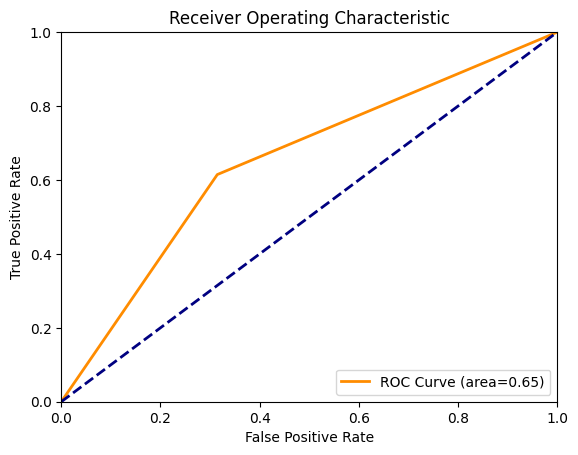

In [ ]:
fpr,tpr,threshold = roc_curve(y_teste,y_pred_teste)

roc_auc = roc_auc_score (y_teste, y_pred_teste)
print("AUC: {:.2f}".format(roc_auc))

plt.figure()
plt.plot(fpr,tpr,color='darkorange', lw=2, label='ROC Curve (area=%0.2f)'%roc_auc)
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.0])
plt.ylabel("True Positive Rate")
plt.xlabel("False Positive Rate")
plt.title("Receiver Operating Characteristic")
plt.legend(loc='lower right')
plt.show()

Já a curva ROC obtida para o modelo apresenta AUC = 0.65, o que indica capacidade discriminativa moderada. O modelo para conseguir distinguir casos positivos de negativos melhor do que o acaso, mas apresenta limitações nos resultados apresentados. Esse resultado é coerente com as correlações fracas que foram observadas na etapa exploratória e com o desbalanceamento dos grupos de cada variável não alvo.

# 7) Explique:

A) Explique com suas palavras regressão logistica.

B) Explique porque a regressão logistica é um modelo de classificação.

C) Explique quais pontos em comum a regressão logistica tem da regressão linear.



Regressão logística é um algoritmo de aprendizado supervisionado usado para classificação, especialmente na forma binária, em que o objetivo é estimar a probabilidade de uma observação pertencer à classe positiva, em função de um conjunto de variáveis explicativas.

O modelo utiliza um preditor linear z, que é construído como uma combinação linear das variáveis de entrada e seus respectivos coeficientes, em seguida esse valor é transformado em probabilidade por meio de uma função logística chamada sigmoide, que restringe a saída a um intervalo entre 0 e 1.

E a classificação final é obtida ao comparar a probabilidade estimada com um limiar de decisão. Valores acima do limiar são atribuídos à classe positiva, e valores abaixo à classe negativa.

O modelo de Regressão logística é considerado um modelo de classificação porque apresenta um resultado categórico a partir do conjunto de entrada. Portanto, o objetivo do modelo é prever a classe de um determinado conjunto de variáveis.

Quando comparamos a estrutura do modelo de regressão logística e regressão linear é possível perceber que ambos modelos seguem a mesma estrutura de preditor linear, já que combinam variáveis explicativas por meio de uma soma ponderada de coeficientes. Em ambos os casos os coeficientes são estimados a partir dos dados, e podem ser interpretados como uma contribuição de cada variável para o resultado final, e podem ser regularizados para reduzir overfitting. No entanto, a maior diferença entre os dois modelos é a função que relaciona o preditor linear a variável alvo. Enquanto a regressão linear retorna o preditor diretamente na saída como variável contínua, a regressão logística utiliza o preditor para gerar probabilidades do resultado se encaixar em classes diferentes.